In [32]:
import warnings
warnings.filterwarnings("ignore")

In [33]:
import torch
import numpy as np
import pandas as pd

from flonacomldft.utils.io_utils import (load_pickle_file,
    get_project_path,
    load_csv_file
)

from flonacomldft.models.mlp import MLP
from flonacomldft.train_mlp_from_data import train_mlp

import matplotlib.pyplot as plt

In [34]:
path_from_adaptive = "/2-adaptive-mlp"
adaptive_to_load = lambda isomer, idx: "results_adaptive_is{:d}_{:d}/adaptive_sampling_is{:d}_{:d}.pkl".format(
        isomer, 
        idx, 
        isomer, 
        idx)

isomer = 0 #1
idx = 32504326 #32510291,

datasets = load_pickle_file(adaptive_to_load(isomer, idx), 
        path = get_project_path() + path_from_adaptive
        )['mlps_datasets']

In [35]:
datasets['train'] = datasets['train'][0]
datasets['test'] = datasets['test'][0]

In [36]:
(1000 + 1000*5 + 500*5 + 300*(50-10))*np.array([0.8, 0.2]),

(array([16400.,  4100.]),)

In [37]:
for key in datasets.keys():
    print("{:s}: ".format(key), datasets[key].shape)

train:  torch.Size([16400, 14])
test:  torch.Size([4100, 14])


In [38]:
dim = 12
n_hidden = 64
n_layers = 4
n_iter = 100000
lr = 5e-4
bs = 1000
use_scheduler = True
step_scheduler = 500
with_tqdm = False

model = MLP([dim] +  [n_hidden] * n_layers + [1])

In [39]:
mlp_dic = train_mlp(model, 
                datasets['train'], 
                datasets['test'], 
                n_iter = n_iter,
                lr = lr,
                bs = bs,
                use_scheduler = use_scheduler,
                step_scheduler = step_scheduler,
                with_tqdm = False,
                dim = dim) 

Number of epochs:  6098
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-04 	 4.70e+01 	 1.88e+02 	 1.7e+01


6.1e+02 	 2.50e-04 	 2.92e-03 	 1.43e-02 	 1.7e+01
1.2e+03 	 1.25e-04 	 1.40e-03 	 7.80e-03 	 1.7e+01
1.8e+03 	 6.25e-05 	 8.74e-04 	 5.26e-03 	 1.7e+01
2.4e+03 	 3.13e-05 	 7.51e-04 	 4.65e-03 	 1.7e+01
3.0e+03 	 7.81e-06 	 7.05e-04 	 4.41e-03 	 1.7e+01
3.7e+03 	 3.91e-06 	 6.86e-04 	 4.29e-03 	 1.7e+01
4.3e+03 	 1.95e-06 	 6.78e-04 	 4.24e-03 	 1.7e+01
4.9e+03 	 9.77e-07 	 6.74e-04 	 4.22e-03 	 1.7e+01
5.5e+03 	 4.88e-07 	 6.72e-04 	 4.21e-03 	 1.7e+01
6.1e+03 	 1.22e-07 	 6.72e-04 	 4.21e-03 	 1.7e+01


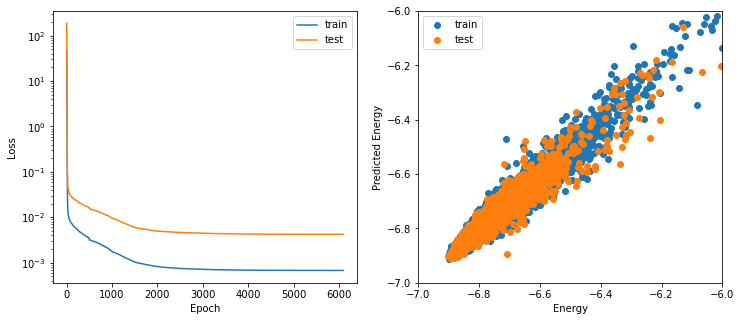

In [40]:
predictions = {}
predictions['train'] = model(datasets['train'][:, :12])
predictions['test'] = model(datasets['test'][:, :12])

fig, ax = plt.subplots(1, 2, figsize = (12, 5))

ax[0].plot(mlp_dic['avg_train_losses'], label = 'train')
ax[0].plot(mlp_dic['avg_test_losses'], label = 'test')
ax[0].legend()
ax[0].set_yscale('log')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')

ax[1].scatter(datasets['train'][:, 12].detach().numpy(),
            predictions['train'].detach().numpy(),
            label = 'train')
ax[1].scatter(datasets['test'][:, 12].detach().numpy(),
            predictions['test'].detach().numpy(),
            label = 'test')
ax[1].legend()
ax[1].set_xlabel('Energy')
ax[1].set_ylabel('Predicted Energy')

ax[1].set_xlim(-7, -6)
ax[1].set_ylim(-7, -6)

plt.show()

In [41]:
#all_losses = {}
#all_losses['train'] = []
#all_losses['test'] = []
#
#for mlp_dic in models:
#    all_losses['train'].append(mlp_dic['avg_train_losses'])
#    all_losses['test'].append(mlp_dic['avg_test_losses'])
#
##flatten the list
#all_losses['train'] = [item for sublist in all_losses['train'] for item in sublist]
#all_losses['test'] = [item for sublist in all_losses['test'] for item in sublist]
#
#fig, ax = plt.subplots(1, 1, figsize = (10, 5))
#ax.plot(all_losses['train'], label = 'train')
#ax.plot(all_losses['test'], label = 'test')
#ax.legend()
#ax.set_yscale('log')
#ax.set_xlabel('Epoch')
#ax.set_ylabel('Loss')

In [42]:
def run_training(isomer, 
        idx,
        hyperparams,
        init_n_samples,
        final_n_samples,
        step_n_samples,
        skip,
        ):

        datasets = load_pickle_file(adaptive_to_load(isomer, idx), 
                path = get_project_path() + path_from_adaptive
                )['mlps_datasets']

        datasets['train'] = datasets['train'][0]
        datasets['test'] = datasets['test'][0]

        old_losses = {} 
        old_losses['train'] = [load_pickle_file(adaptive_to_load(isomer, idx),
                path = get_project_path() + path_from_adaptive
                )['dict_mlps'][i][0]['avg_train_losses'] for i in range(10)]
        old_losses['test'] = [load_pickle_file(adaptive_to_load(isomer, idx),
                path = get_project_path() + path_from_adaptive
                )['dict_mlps'][i][0]['avg_test_losses'] for i in range(10)]
        
        old_losses['train'] = [item for sublist in old_losses['train'] for item in sublist]
        old_losses['test'] = [item for sublist in old_losses['test'] for item in sublist]
        
        dim = hyperparams['dim']
        n_hidden = hyperparams['n_hidden']
        n_layers = hyperparams['n_layers']
        n_iter = hyperparams['n_iter']
        lr = hyperparams['lr']
        bs = hyperparams['bs']
        use_scheduler = hyperparams['use_scheduler']
        step_scheduler = hyperparams['step_scheduler']
        with_tqdm = hyperparams['with_tqdm']

        model = MLP([dim] +  [n_hidden] * n_layers + [1])

        models = []

        list_n_samples = [1000, 
                        1000+1000*5, 
                        1000+1000*5+500*5, 
                        1000+1000*5+500*5+300*5] + [1000+1000*5+500*5+300*(i-10) for i in range(10, 50, 5)]
        
        #for i, N_samples in enumerate(np.arange(init_n_samples, final_n_samples, step_n_samples)[::skip][:]):
        for i, N_samples in enumerate(list_n_samples[::skip][:]):
            print("N_samples: ", N_samples)
            print("N_samples*0.8: ", int(N_samples*0.8))
            print("N_samples*0.2: ", int(N_samples*0.2))
            print('N iterations: ', n_iter)
            print('Batch size: ', bs)
            print('Learning rate: ', lr)

            final = {'train': int(N_samples*0.8), 'test': int(N_samples*0.2)}

            mlp_dic = train_mlp(model, 
                            datasets['train'][:final['train']], 
                            datasets['test'][:final['test']], 
                            n_iter = n_iter,
                            lr = lr,
                            bs = bs,
                            use_scheduler = use_scheduler,
                            step_scheduler = step_scheduler,
                            with_tqdm = False,
                            dim = dim)

            models.append(mlp_dic)

            model = mlp_dic['model']

            predictions = {}
            predictions['train'] = model(datasets['train'][:final['test'], :12])
            predictions['test'] = model(datasets['test'][:final['test'], :12])

            fig, ax = plt.subplots(1, 2, figsize = (12, 5))

            ax[0].plot(mlp_dic['avg_train_losses'], label = 'train')
            ax[0].plot(mlp_dic['avg_test_losses'], label = 'test')
            ax[0].legend()
            ax[0].set_yscale('log')
            ax[0].set_xlabel('Epoch')
            ax[0].set_ylabel('Loss')

            ax[1].scatter(datasets['train'][:final['test'], 12].detach().numpy(),
                        predictions['train'].detach().numpy(),
                        label = 'train')
            ax[1].scatter(datasets['test'][:final['test'], 12].detach().numpy(),
                        predictions['test'].detach().numpy(),
                        label = 'test')
            ax[1].legend()
            ax[1].set_xlabel('Energy')
            ax[1].set_ylabel('Predicted Energy')
            
            fig.suptitle('Isomer {:d}, Cycle {:d}'.format(isomer, i*skip-1))

            #ax[1].set_xlim(-7, -6)
            #ax[1].set_ylim(-7, -6)

            plt.show()

            n_iter = 30000 #+ 5000*i
            #n_iter = int(n_iter/2) + 3000*i

        all_losses = {}
        all_losses['train'] = []
        all_losses['test'] = []
        
        for mlp_dic in models:
            all_losses['train'].append(mlp_dic['avg_train_losses'])
            all_losses['test'].append(mlp_dic['avg_test_losses'])
        
        #flatten the list
        all_losses['train'] = [item for sublist in all_losses['train'] for item in sublist]
        all_losses['test'] = [item for sublist in all_losses['test'] for item in sublist]
        
        fig, ax = plt.subplots(1, 1, figsize = (10, 5))
        ax.plot(all_losses['train'], label = 'train')
        ax.plot(all_losses['test'], label = 'test')
        ax.plot(old_losses['train'], label = 'old train', linestyle = '--')
        ax.plot(old_losses['test'], label = 'old test', linestyle = '--')
        ax.legend()
        ax.set_yscale('log')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')

        fig.suptitle('Isomer {:d}, MLP training stages'.format(isomer, i*skip-1))

        return models, all_losses   

        

N_samples:  1000
N_samples*0.8:  800
N_samples*0.2:  200
N iterations:  25000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  25000
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 5.47e+01 	 2.18e+02 	 1.6e+01
2.5e+03 	 5.00e-05 	 1.93e-02 	 1.04e-01 	 6.8e-02
5.0e+03 	 5.00e-05 	 5.43e-03 	 4.97e-02 	 9.2e-03
7.5e+03 	 5.00e-05 	 2.80e-03 	 4.02e-02 	 3.8e-03
1.0e+04 	 5.00e-05 	 1.47e-03 	 3.70e-02 	 4.9e-03
1.2e+04 	 5.00e-05 	 6.57e-04 	 3.24e-02 	 2.3e-02
1.5e+04 	 5.00e-05 	 3.09e-04 	 3.26e-02 	 1.6e-02
1.8e+04 	 5.00e-05 	 1.73e-04 	 3.30e-02 	 1.6e-02
2.0e+04 	 5.00e-05 	 1.19e-04 	 3.35e-02 	 1.1e-03
2.2e+04 	 5.00e-05 	 9.60e-05 	 3.37e-02 	 4.6e-02


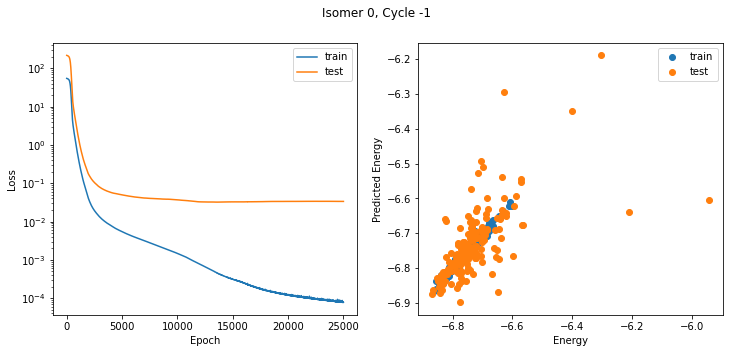

N_samples:  6000
N_samples*0.8:  4800
N_samples*0.2:  1200
N iterations:  30000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  6250
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 1.38e-02 	 5.90e-02 	 2.5e-01
6.2e+02 	 5.00e-05 	 6.93e-03 	 3.61e-02 	 3.6e-02
1.2e+03 	 5.00e-05 	 4.90e-03 	 2.78e-02 	 4.5e-02
1.9e+03 	 5.00e-05 	 3.33e-03 	 2.05e-02 	 1.7e-01
2.5e+03 	 5.00e-05 	 2.45e-03 	 1.64e-02 	 1.6e-01
3.1e+03 	 5.00e-05 	 1.88e-03 	 1.41e-02 	 1.4e-01
3.8e+03 	 5.00e-05 	 1.51e-03 	 1.27e-02 	 1.6e-01
4.4e+03 	 5.00e-05 	 1.26e-03 	 1.12e-02 	 4.4e-02
5.0e+03 	 5.00e-05 	 1.08e-03 	 1.01e-02 	 1.6e-01
5.6e+03 	 5.00e-05 	 9.67e-04 	 9.52e-03 	 1.3e-01


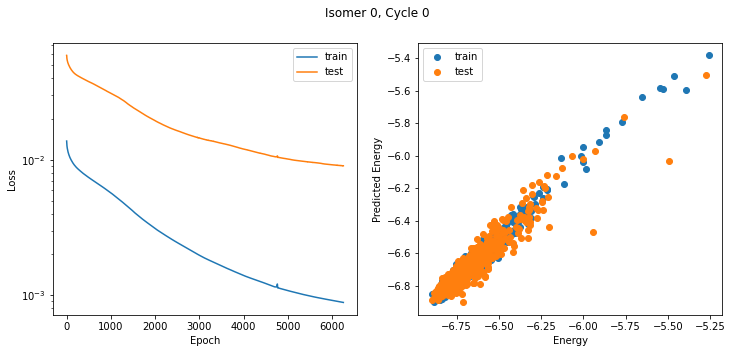

N_samples:  8500
N_samples*0.8:  6800
N_samples*0.2:  1700
N iterations:  30000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  4412
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 1.59e-03 	 9.67e-03 	 5.4e-01
4.4e+02 	 5.00e-05 	 9.51e-04 	 7.39e-03 	 5.4e-01
8.8e+02 	 5.00e-05 	 8.82e-04 	 7.06e-03 	 5.4e-01
1.3e+03 	 5.00e-05 	 8.07e-04 	 6.72e-03 	 5.4e-01
1.8e+03 	 5.00e-05 	 7.49e-04 	 6.50e-03 	 5.4e-01
2.2e+03 	 5.00e-05 	 6.95e-04 	 6.23e-03 	 5.4e-01
2.6e+03 	 5.00e-05 	 6.51e-04 	 6.01e-03 	 5.4e-01
3.1e+03 	 5.00e-05 	 6.13e-04 	 5.82e-03 	 5.4e-01
3.5e+03 	 5.00e-05 	 5.81e-04 	 5.69e-03 	 5.4e-01
4.0e+03 	 5.00e-05 	 5.52e-04 	 5.57e-03 	 5.4e-01
4.4e+03 	 5.00e-05 	 5.27e-04 	 5.44e-03 	 5.4e-01


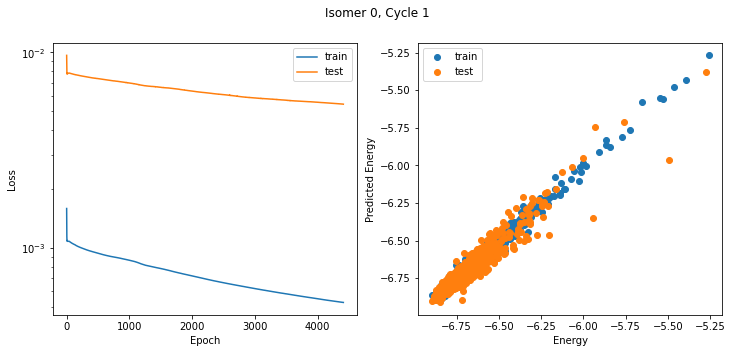

N_samples:  10000
N_samples*0.8:  8000
N_samples*0.2:  2000
N iterations:  30000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  3750
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 1.49e-03 	 6.71e-03 	 2.4e-01
3.8e+02 	 5.00e-05 	 6.17e-04 	 5.09e-03 	 1.1e-01
7.5e+02 	 5.00e-05 	 5.61e-04 	 5.04e-03 	 8.9e-02
1.1e+03 	 5.00e-05 	 5.23e-04 	 4.94e-03 	 7.2e-02
1.5e+03 	 5.00e-05 	 4.94e-04 	 4.85e-03 	 4.7e-02
1.9e+03 	 5.00e-05 	 4.72e-04 	 4.78e-03 	 4.1e-02
2.2e+03 	 5.00e-05 	 4.52e-04 	 4.67e-03 	 6.9e-02
2.6e+03 	 5.00e-05 	 4.35e-04 	 4.60e-03 	 7.2e-02
3.0e+03 	 5.00e-05 	 4.18e-04 	 4.52e-03 	 5.7e-02
3.4e+03 	 5.00e-05 	 4.03e-04 	 4.39e-03 	 6.5e-02


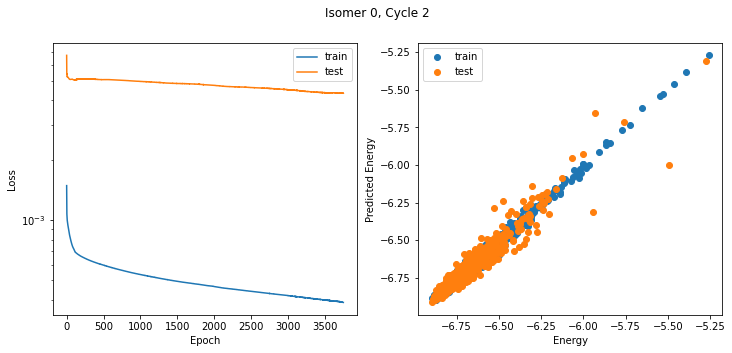

N_samples:  8500
N_samples*0.8:  6800
N_samples*0.2:  1700
N iterations:  30000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  4412
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 7.85e-04 	 6.25e-03 	 3.2e-01
4.4e+02 	 5.00e-05 	 3.62e-04 	 4.50e-03 	 3.2e-01
8.8e+02 	 5.00e-05 	 3.42e-04 	 4.33e-03 	 3.2e-01
1.3e+03 	 5.00e-05 	 3.27e-04 	 4.23e-03 	 3.2e-01
1.8e+03 	 5.00e-05 	 3.15e-04 	 4.16e-03 	 3.2e-01
2.2e+03 	 5.00e-05 	 3.05e-04 	 4.10e-03 	 3.2e-01
2.6e+03 	 5.00e-05 	 2.95e-04 	 4.07e-03 	 3.2e-01
3.1e+03 	 5.00e-05 	 2.86e-04 	 4.02e-03 	 3.2e-01
3.5e+03 	 5.00e-05 	 2.79e-04 	 3.98e-03 	 3.2e-01
4.0e+03 	 5.00e-05 	 2.71e-04 	 3.87e-03 	 3.2e-01
4.4e+03 	 5.00e-05 	 2.64e-04 	 3.80e-03 	 3.2e-01


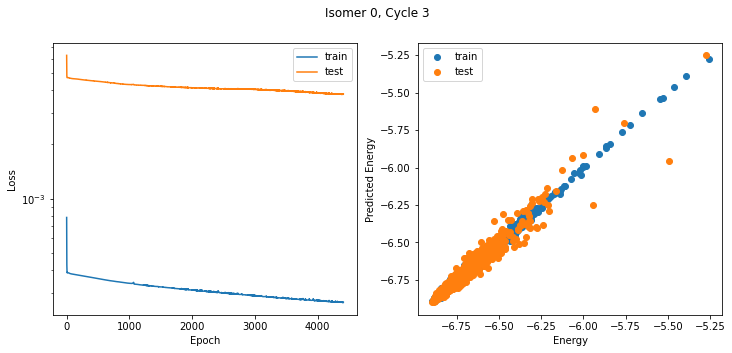

N_samples:  10000
N_samples*0.8:  8000
N_samples*0.2:  2000
N iterations:  30000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  3750
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 6.55e-04 	 4.59e-03 	 4.9e-01
3.8e+02 	 5.00e-05 	 2.94e-04 	 3.67e-03 	 6.3e-02
7.5e+02 	 5.00e-05 	 2.82e-04 	 3.65e-03 	 5.2e-02
1.1e+03 	 5.00e-05 	 2.73e-04 	 3.64e-03 	 4.7e-02
1.5e+03 	 5.00e-05 	 2.64e-04 	 3.61e-03 	 1.5e-02
1.9e+03 	 5.00e-05 	 2.57e-04 	 3.58e-03 	 2.4e-02
2.2e+03 	 5.00e-05 	 2.51e-04 	 3.54e-03 	 2.7e-02
2.6e+03 	 5.00e-05 	 2.44e-04 	 3.52e-03 	 2.1e-02
3.0e+03 	 5.00e-05 	 2.41e-04 	 3.49e-03 	 3.7e-02
3.4e+03 	 5.00e-05 	 2.35e-04 	 3.47e-03 	 2.4e-02


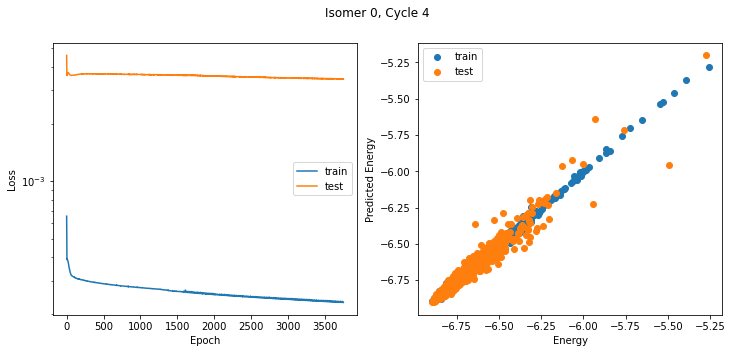

N_samples:  11500
N_samples*0.8:  9200
N_samples*0.2:  2300
N iterations:  30000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  3261
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 1.76e-03 	 5.34e-03 	 5.8e-01
3.3e+02 	 5.00e-05 	 4.34e-04 	 3.81e-03 	 5.8e-01
6.5e+02 	 5.00e-05 	 3.50e-04 	 3.70e-03 	 5.8e-01
9.8e+02 	 5.00e-05 	 3.16e-04 	 3.62e-03 	 5.8e-01
1.3e+03 	 5.00e-05 	 2.96e-04 	 3.52e-03 	 5.8e-01
1.6e+03 	 5.00e-05 	 2.81e-04 	 3.45e-03 	 5.8e-01
2.0e+03 	 5.00e-05 	 2.71e-04 	 3.39e-03 	 5.8e-01
2.3e+03 	 5.00e-05 	 2.62e-04 	 3.37e-03 	 5.8e-01
2.6e+03 	 5.00e-05 	 2.55e-04 	 3.36e-03 	 5.8e-01
2.9e+03 	 5.00e-05 	 2.49e-04 	 3.31e-03 	 5.8e-01
3.3e+03 	 5.00e-05 	 2.43e-04 	 3.30e-03 	 5.8e-01


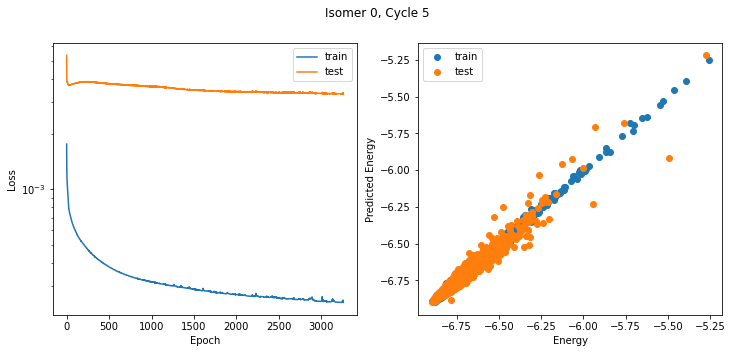

N_samples:  13000
N_samples*0.8:  10400
N_samples*0.2:  2600
N iterations:  30000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  2885
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 5.15e-04 	 3.95e-03 	 1.8e-01
2.9e+02 	 5.00e-05 	 2.68e-04 	 3.01e-03 	 1.8e-01
5.8e+02 	 5.00e-05 	 2.60e-04 	 2.97e-03 	 1.8e-01
8.6e+02 	 5.00e-05 	 2.54e-04 	 2.94e-03 	 1.8e-01
1.2e+03 	 5.00e-05 	 2.48e-04 	 2.92e-03 	 1.8e-01
1.4e+03 	 5.00e-05 	 2.45e-04 	 2.90e-03 	 1.8e-01
1.7e+03 	 5.00e-05 	 2.39e-04 	 2.88e-03 	 1.8e-01
2.0e+03 	 5.00e-05 	 2.37e-04 	 2.87e-03 	 1.8e-01
2.3e+03 	 5.00e-05 	 2.32e-04 	 2.85e-03 	 1.8e-01
2.6e+03 	 5.00e-05 	 2.30e-04 	 2.82e-03 	 1.8e-01
2.9e+03 	 5.00e-05 	 2.27e-04 	 2.83e-03 	 1.8e-01


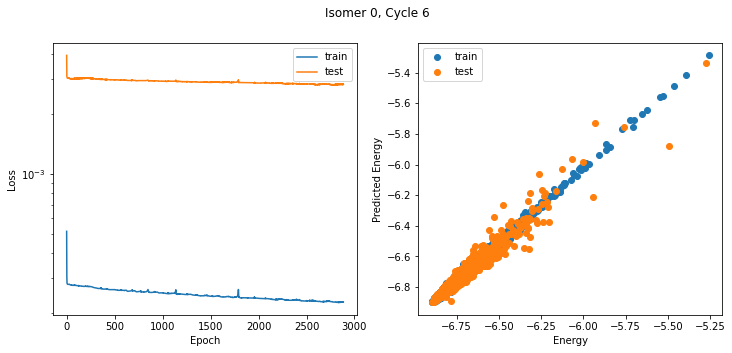

N_samples:  14500
N_samples*0.8:  11600
N_samples*0.2:  2900
N iterations:  30000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  2586
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 5.53e-04 	 3.83e-03 	 3.0e-01
2.6e+02 	 5.00e-05 	 2.33e-04 	 2.57e-03 	 3.0e-01
5.2e+02 	 5.00e-05 	 2.31e-04 	 2.55e-03 	 3.0e-01
7.7e+02 	 5.00e-05 	 2.25e-04 	 2.54e-03 	 3.0e-01
1.0e+03 	 5.00e-05 	 2.25e-04 	 2.55e-03 	 3.0e-01
1.3e+03 	 5.00e-05 	 2.22e-04 	 2.54e-03 	 3.0e-01
1.5e+03 	 5.00e-05 	 2.20e-04 	 2.54e-03 	 3.0e-01
1.8e+03 	 5.00e-05 	 2.22e-04 	 2.58e-03 	 3.0e-01
2.1e+03 	 5.00e-05 	 2.14e-04 	 2.56e-03 	 3.0e-01
2.3e+03 	 5.00e-05 	 2.12e-04 	 2.57e-03 	 3.0e-01
2.6e+03 	 5.00e-05 	 2.10e-04 	 2.60e-03 	 3.0e-01


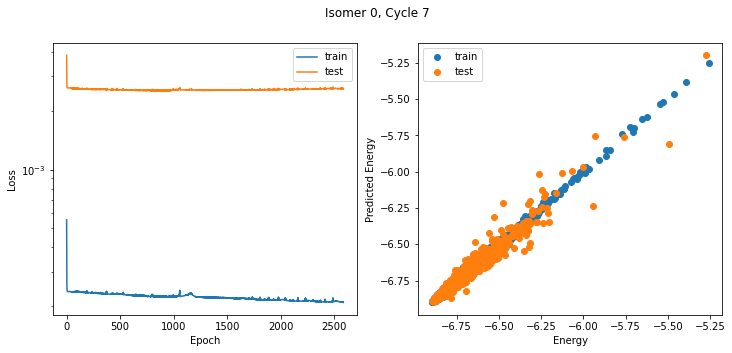

N_samples:  16000
N_samples*0.8:  12800
N_samples*0.2:  3200
N iterations:  30000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  2344
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 3.54e-04 	 2.95e-03 	 2.9e-01
2.3e+02 	 5.00e-05 	 2.12e-04 	 2.42e-03 	 2.9e-01
4.7e+02 	 5.00e-05 	 2.10e-04 	 2.42e-03 	 2.9e-01
7.0e+02 	 5.00e-05 	 2.07e-04 	 2.42e-03 	 2.9e-01
9.4e+02 	 5.00e-05 	 2.04e-04 	 2.41e-03 	 2.9e-01
1.2e+03 	 5.00e-05 	 2.01e-04 	 2.41e-03 	 2.9e-01
1.4e+03 	 5.00e-05 	 1.99e-04 	 2.42e-03 	 2.9e-01
1.6e+03 	 5.00e-05 	 1.98e-04 	 2.43e-03 	 2.9e-01
1.9e+03 	 5.00e-05 	 1.96e-04 	 2.42e-03 	 2.9e-01
2.1e+03 	 5.00e-05 	 1.95e-04 	 2.43e-03 	 2.9e-01
2.3e+03 	 5.00e-05 	 1.94e-04 	 2.42e-03 	 2.9e-01


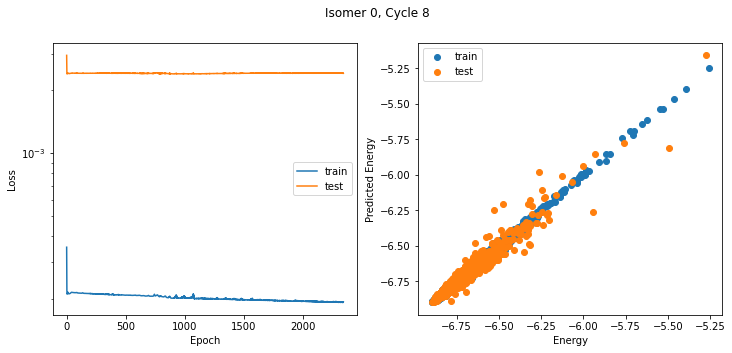

N_samples:  17500
N_samples*0.8:  14000
N_samples*0.2:  3500
N iterations:  30000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  2143
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 3.13e-04 	 2.75e-03 	 3.1e-01
2.1e+02 	 5.00e-05 	 1.92e-04 	 2.32e-03 	 3.1e-01
4.3e+02 	 5.00e-05 	 1.92e-04 	 2.31e-03 	 3.1e-01
6.4e+02 	 5.00e-05 	 1.89e-04 	 2.33e-03 	 3.1e-01
8.6e+02 	 5.00e-05 	 1.93e-04 	 2.40e-03 	 3.1e-01
1.1e+03 	 5.00e-05 	 1.85e-04 	 2.33e-03 	 3.1e-01
1.3e+03 	 5.00e-05 	 1.84e-04 	 2.30e-03 	 3.1e-01
1.5e+03 	 5.00e-05 	 1.82e-04 	 2.28e-03 	 3.1e-01
1.7e+03 	 5.00e-05 	 1.80e-04 	 2.28e-03 	 3.1e-01
1.9e+03 	 5.00e-05 	 1.79e-04 	 2.29e-03 	 3.1e-01
2.1e+03 	 5.00e-05 	 1.78e-04 	 2.29e-03 	 3.1e-01


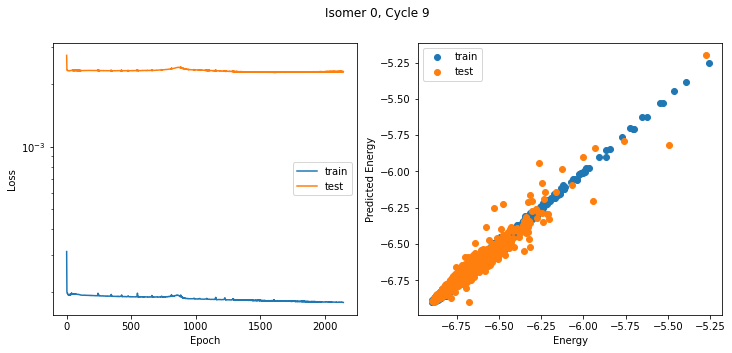

N_samples:  19000
N_samples*0.8:  15200
N_samples*0.2:  3800
N iterations:  30000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  1974
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 3.29e-04 	 2.87e-03 	 1.7e-01
2.0e+02 	 5.00e-05 	 1.89e-04 	 2.28e-03 	 1.7e-01
3.9e+02 	 5.00e-05 	 1.87e-04 	 2.26e-03 	 1.7e-01
5.9e+02 	 5.00e-05 	 1.85e-04 	 2.25e-03 	 1.7e-01
7.9e+02 	 5.00e-05 	 1.84e-04 	 2.24e-03 	 1.7e-01
9.8e+02 	 5.00e-05 	 1.83e-04 	 2.24e-03 	 1.7e-01
1.2e+03 	 5.00e-05 	 1.81e-04 	 2.22e-03 	 1.7e-01
1.4e+03 	 5.00e-05 	 1.81e-04 	 2.22e-03 	 1.7e-01
1.6e+03 	 5.00e-05 	 1.78e-04 	 2.20e-03 	 1.7e-01
1.8e+03 	 5.00e-05 	 1.77e-04 	 2.17e-03 	 1.7e-01
2.0e+03 	 5.00e-05 	 1.76e-04 	 2.15e-03 	 1.7e-01


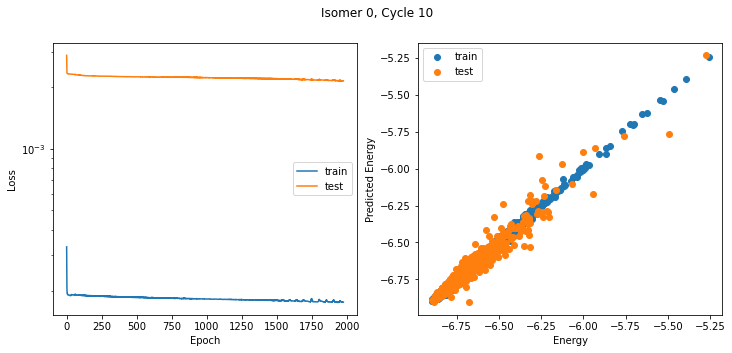

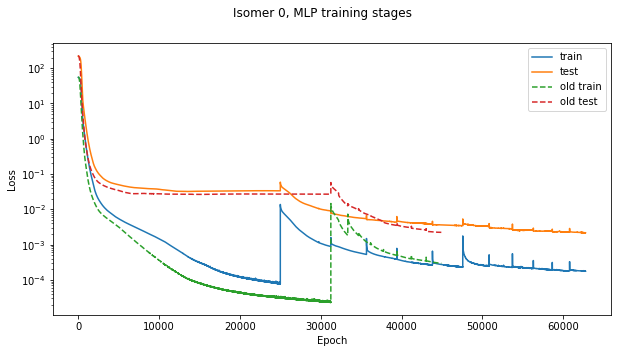

In [43]:
isomer = 0
idx = 32504326#31959910
hyperparams = {'dim': 12, 
'n_hidden': 64, 
'n_layers': 4, 
'n_iter': 25000, 
'lr': 5e-5, 
'bs': 1000,
'use_scheduler': False, 
'step_scheduler': 100, 
'with_tqdm': False}
init_n_samples = 1000
final_n_samples = 16000
step_n_samples = 300
skip = 1

models_is0, all_losses_is0 = run_training(isomer,
        idx,
        hyperparams,
        init_n_samples,
        final_n_samples,
        step_n_samples,
        skip)


N_samples:  1000
N_samples*0.8:  800
N_samples*0.2:  200
N iterations:  25000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  25000
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 5.66e+01 	 2.25e+02 	 1.6e+01
2.5e+03 	 5.00e-05 	 1.45e-02 	 7.60e-02 	 9.3e-02
5.0e+03 	 5.00e-05 	 3.88e-03 	 2.17e-02 	 6.7e-03
7.5e+03 	 5.00e-05 	 2.31e-03 	 1.76e-02 	 2.9e-03
1.0e+04 	 5.00e-05 	 1.39e-03 	 1.70e-02 	 4.1e-03
1.2e+04 	 5.00e-05 	 7.88e-04 	 1.79e-02 	 2.6e-02
1.5e+04 	 5.00e-05 	 4.74e-04 	 1.59e-02 	 3.9e-02
1.8e+04 	 5.00e-05 	 3.25e-04 	 1.41e-02 	 2.1e-02
2.0e+04 	 5.00e-05 	 2.33e-04 	 1.39e-02 	 3.2e-02
2.2e+04 	 5.00e-05 	 1.74e-04 	 1.36e-02 	 3.5e-02


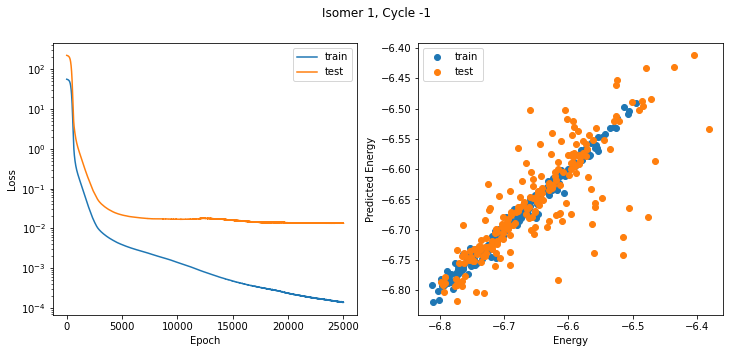

N_samples:  6000
N_samples*0.8:  4800
N_samples*0.2:  1200
N iterations:  30000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  6250
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 5.65e-03 	 1.92e-02 	 3.5e-01
6.2e+02 	 5.00e-05 	 2.12e-03 	 1.06e-02 	 8.8e-02
1.2e+03 	 5.00e-05 	 1.47e-03 	 8.50e-03 	 2.6e-02
1.9e+03 	 5.00e-05 	 1.14e-03 	 7.01e-03 	 3.4e-02
2.5e+03 	 5.00e-05 	 9.48e-04 	 5.93e-03 	 9.8e-02
3.1e+03 	 5.00e-05 	 8.39e-04 	 5.50e-03 	 1.3e-01
3.8e+03 	 5.00e-05 	 7.66e-04 	 5.36e-03 	 1.4e-01
4.4e+03 	 5.00e-05 	 6.96e-04 	 5.34e-03 	 1.5e-01
5.0e+03 	 5.00e-05 	 6.40e-04 	 5.28e-03 	 1.5e-01
5.6e+03 	 5.00e-05 	 5.92e-04 	 5.12e-03 	 1.4e-01


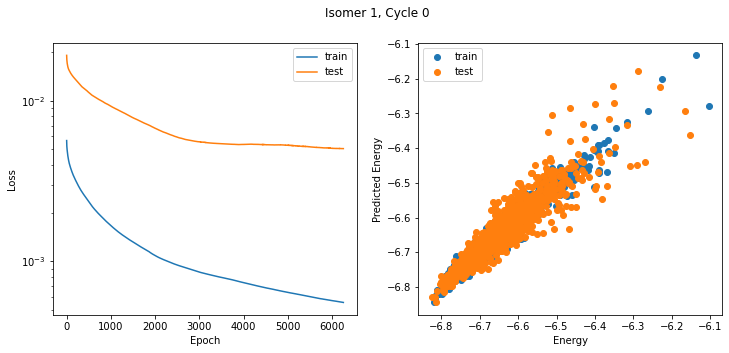

N_samples:  8500
N_samples*0.8:  6800
N_samples*0.2:  1700
N iterations:  30000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  4412
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 8.11e-04 	 5.38e-03 	 3.3e-02
4.4e+02 	 5.00e-05 	 5.49e-04 	 4.25e-03 	 3.3e-02
8.8e+02 	 5.00e-05 	 5.07e-04 	 4.09e-03 	 3.3e-02
1.3e+03 	 5.00e-05 	 4.82e-04 	 4.00e-03 	 3.3e-02
1.8e+03 	 5.00e-05 	 4.59e-04 	 3.87e-03 	 3.3e-02
2.2e+03 	 5.00e-05 	 4.39e-04 	 3.78e-03 	 3.3e-02
2.6e+03 	 5.00e-05 	 4.19e-04 	 3.67e-03 	 3.3e-02
3.1e+03 	 5.00e-05 	 4.04e-04 	 3.61e-03 	 3.3e-02
3.5e+03 	 5.00e-05 	 3.91e-04 	 3.59e-03 	 3.3e-02
4.0e+03 	 5.00e-05 	 3.79e-04 	 3.55e-03 	 3.3e-02
4.4e+03 	 5.00e-05 	 3.67e-04 	 3.57e-03 	 3.3e-02


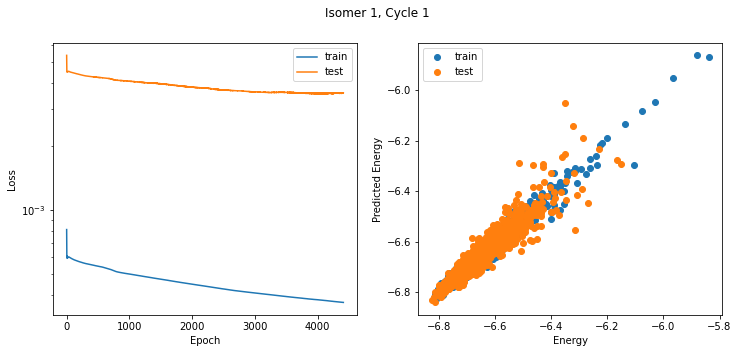

N_samples:  10000
N_samples*0.8:  8000
N_samples*0.2:  2000
N iterations:  30000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  3750
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 7.35e-04 	 4.28e-03 	 4.6e-02
3.8e+02 	 5.00e-05 	 3.76e-04 	 3.03e-03 	 5.1e-02
7.5e+02 	 5.00e-05 	 3.58e-04 	 2.91e-03 	 5.1e-02
1.1e+03 	 5.00e-05 	 3.46e-04 	 2.81e-03 	 5.0e-02
1.5e+03 	 5.00e-05 	 3.34e-04 	 2.71e-03 	 4.0e-02
1.9e+03 	 5.00e-05 	 3.24e-04 	 2.66e-03 	 7.8e-03
2.2e+03 	 5.00e-05 	 3.12e-04 	 2.65e-03 	 6.6e-03
2.6e+03 	 5.00e-05 	 3.03e-04 	 2.59e-03 	 6.0e-03
3.0e+03 	 5.00e-05 	 2.95e-04 	 2.57e-03 	 8.4e-03
3.4e+03 	 5.00e-05 	 2.87e-04 	 2.48e-03 	 2.2e-02


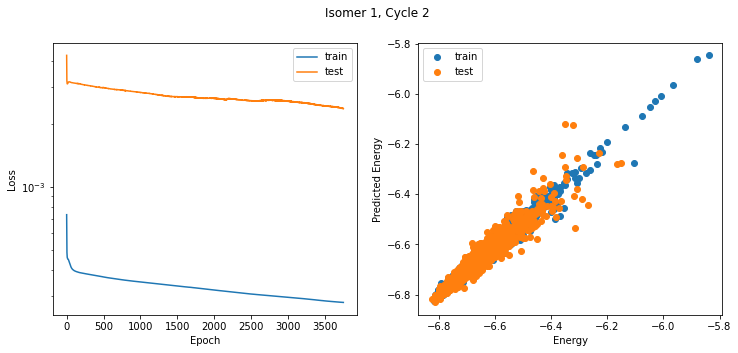

N_samples:  8500
N_samples*0.8:  6800
N_samples*0.2:  1700
N iterations:  30000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  4412
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 5.49e-04 	 3.65e-03 	 2.6e-01
4.4e+02 	 5.00e-05 	 2.75e-04 	 2.50e-03 	 2.6e-01
8.8e+02 	 5.00e-05 	 2.68e-04 	 2.46e-03 	 2.6e-01
1.3e+03 	 5.00e-05 	 2.61e-04 	 2.43e-03 	 2.6e-01
1.8e+03 	 5.00e-05 	 2.56e-04 	 2.41e-03 	 2.6e-01
2.2e+03 	 5.00e-05 	 2.52e-04 	 2.38e-03 	 2.6e-01
2.6e+03 	 5.00e-05 	 2.47e-04 	 2.34e-03 	 2.6e-01
3.1e+03 	 5.00e-05 	 2.43e-04 	 2.31e-03 	 2.6e-01
3.5e+03 	 5.00e-05 	 2.40e-04 	 2.30e-03 	 2.6e-01
4.0e+03 	 5.00e-05 	 2.35e-04 	 2.27e-03 	 2.6e-01
4.4e+03 	 5.00e-05 	 2.31e-04 	 2.26e-03 	 2.6e-01


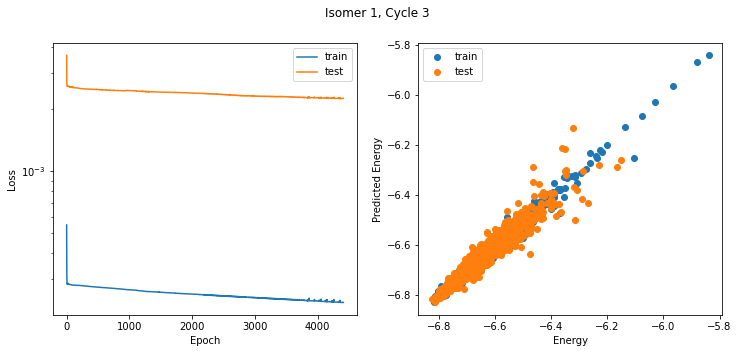

N_samples:  10000
N_samples*0.8:  8000
N_samples*0.2:  2000
N iterations:  30000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  3750
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 4.29e-04 	 2.83e-03 	 3.6e-01
3.8e+02 	 5.00e-05 	 2.38e-04 	 2.01e-03 	 2.8e-02
7.5e+02 	 5.00e-05 	 2.32e-04 	 2.00e-03 	 2.2e-02
1.1e+03 	 5.00e-05 	 2.28e-04 	 2.02e-03 	 1.1e-02
1.5e+03 	 5.00e-05 	 2.24e-04 	 2.10e-03 	 6.1e-03
1.9e+03 	 5.00e-05 	 2.21e-04 	 2.24e-03 	 4.8e-03
2.2e+03 	 5.00e-05 	 2.18e-04 	 2.27e-03 	 4.8e-03
2.6e+03 	 5.00e-05 	 2.15e-04 	 2.29e-03 	 1.7e-02
3.0e+03 	 5.00e-05 	 2.13e-04 	 2.27e-03 	 3.8e-02
3.4e+03 	 5.00e-05 	 2.09e-04 	 2.24e-03 	 2.7e-02


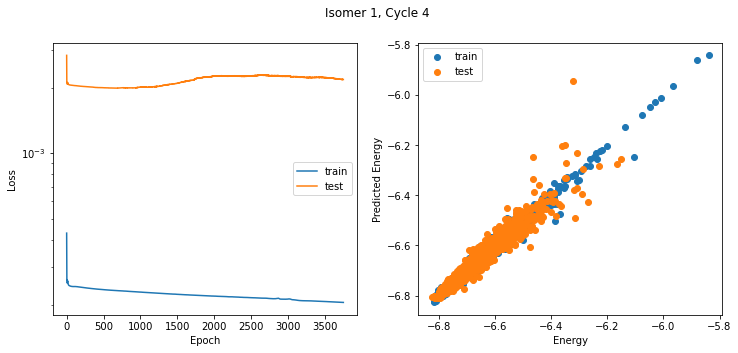

N_samples:  11500
N_samples*0.8:  9200
N_samples*0.2:  2300
N iterations:  30000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  3261
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 4.69e-04 	 3.27e-03 	 4.9e-01
3.3e+02 	 5.00e-05 	 2.29e-04 	 2.19e-03 	 4.9e-01
6.5e+02 	 5.00e-05 	 2.24e-04 	 2.11e-03 	 4.9e-01
9.8e+02 	 5.00e-05 	 2.21e-04 	 2.05e-03 	 4.9e-01
1.3e+03 	 5.00e-05 	 2.18e-04 	 2.01e-03 	 4.9e-01
1.6e+03 	 5.00e-05 	 2.15e-04 	 2.00e-03 	 4.9e-01
2.0e+03 	 5.00e-05 	 2.13e-04 	 2.00e-03 	 4.9e-01
2.3e+03 	 5.00e-05 	 2.11e-04 	 2.04e-03 	 4.9e-01
2.6e+03 	 5.00e-05 	 2.08e-04 	 2.08e-03 	 4.9e-01
2.9e+03 	 5.00e-05 	 2.05e-04 	 2.12e-03 	 4.9e-01
3.3e+03 	 5.00e-05 	 2.06e-04 	 2.18e-03 	 4.9e-01


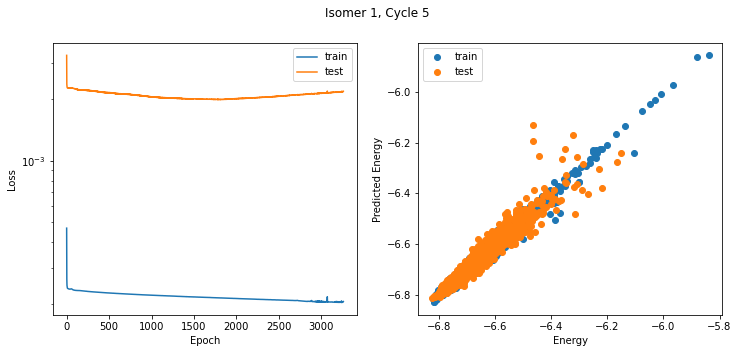

N_samples:  13000
N_samples*0.8:  10400
N_samples*0.2:  2600
N iterations:  30000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  2885
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 4.59e-04 	 2.99e-03 	 5.0e-01
2.9e+02 	 5.00e-05 	 2.02e-04 	 1.99e-03 	 5.0e-01
5.8e+02 	 5.00e-05 	 1.99e-04 	 2.02e-03 	 5.0e-01
8.6e+02 	 5.00e-05 	 1.97e-04 	 2.09e-03 	 5.0e-01
1.2e+03 	 5.00e-05 	 1.96e-04 	 2.12e-03 	 5.0e-01
1.4e+03 	 5.00e-05 	 1.94e-04 	 2.13e-03 	 5.0e-01
1.7e+03 	 5.00e-05 	 1.93e-04 	 2.13e-03 	 5.0e-01
2.0e+03 	 5.00e-05 	 1.91e-04 	 2.14e-03 	 5.0e-01
2.3e+03 	 5.00e-05 	 1.90e-04 	 2.17e-03 	 5.0e-01
2.6e+03 	 5.00e-05 	 1.89e-04 	 2.19e-03 	 5.0e-01
2.9e+03 	 5.00e-05 	 1.88e-04 	 2.20e-03 	 5.0e-01


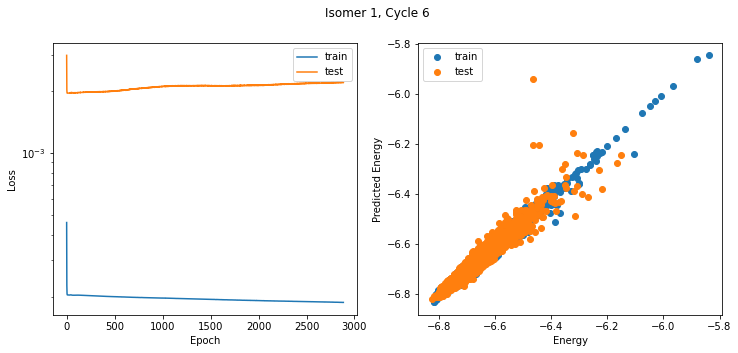

N_samples:  14500
N_samples*0.8:  11600
N_samples*0.2:  2900
N iterations:  30000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  2586
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 3.86e-04 	 2.77e-03 	 2.2e-01
2.6e+02 	 5.00e-05 	 1.84e-04 	 2.07e-03 	 2.2e-01
5.2e+02 	 5.00e-05 	 1.82e-04 	 2.13e-03 	 2.2e-01
7.7e+02 	 5.00e-05 	 1.81e-04 	 2.19e-03 	 2.2e-01
1.0e+03 	 5.00e-05 	 1.79e-04 	 2.21e-03 	 2.2e-01
1.3e+03 	 5.00e-05 	 1.78e-04 	 2.22e-03 	 2.2e-01
1.5e+03 	 5.00e-05 	 1.77e-04 	 2.27e-03 	 2.2e-01
1.8e+03 	 5.00e-05 	 1.76e-04 	 2.33e-03 	 2.2e-01
2.1e+03 	 5.00e-05 	 1.75e-04 	 2.36e-03 	 2.2e-01
2.3e+03 	 5.00e-05 	 1.74e-04 	 2.39e-03 	 2.2e-01
2.6e+03 	 5.00e-05 	 1.73e-04 	 2.37e-03 	 2.2e-01


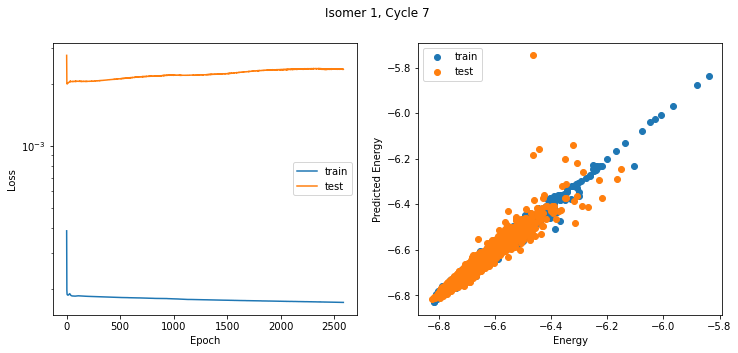

N_samples:  16000
N_samples*0.8:  12800
N_samples*0.2:  3200
N iterations:  30000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  2344
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 3.58e-04 	 2.85e-03 	 5.6e-02
2.3e+02 	 5.00e-05 	 1.66e-04 	 2.17e-03 	 5.6e-02
4.7e+02 	 5.00e-05 	 1.65e-04 	 2.15e-03 	 5.6e-02
7.0e+02 	 5.00e-05 	 1.64e-04 	 2.14e-03 	 5.6e-02
9.4e+02 	 5.00e-05 	 1.63e-04 	 2.15e-03 	 5.6e-02
1.2e+03 	 5.00e-05 	 1.62e-04 	 2.17e-03 	 5.6e-02
1.4e+03 	 5.00e-05 	 1.61e-04 	 2.16e-03 	 5.6e-02
1.6e+03 	 5.00e-05 	 1.60e-04 	 2.17e-03 	 5.6e-02
1.9e+03 	 5.00e-05 	 1.59e-04 	 2.19e-03 	 5.6e-02
2.1e+03 	 5.00e-05 	 1.59e-04 	 2.20e-03 	 5.6e-02
2.3e+03 	 5.00e-05 	 1.58e-04 	 2.20e-03 	 5.6e-02


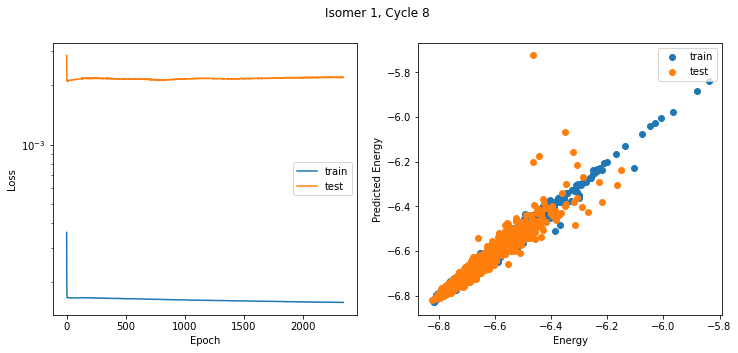

N_samples:  17500
N_samples*0.8:  14000
N_samples*0.2:  3500
N iterations:  30000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  2143
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 3.31e-04 	 2.74e-03 	 1.3e-01
2.1e+02 	 5.00e-05 	 1.53e-04 	 2.06e-03 	 1.3e-01
4.3e+02 	 5.00e-05 	 1.52e-04 	 2.08e-03 	 1.3e-01
6.4e+02 	 5.00e-05 	 1.52e-04 	 2.06e-03 	 1.3e-01
8.6e+02 	 5.00e-05 	 1.51e-04 	 2.09e-03 	 1.3e-01
1.1e+03 	 5.00e-05 	 1.50e-04 	 2.09e-03 	 1.3e-01
1.3e+03 	 5.00e-05 	 1.50e-04 	 2.08e-03 	 1.3e-01
1.5e+03 	 5.00e-05 	 1.49e-04 	 2.05e-03 	 1.3e-01
1.7e+03 	 5.00e-05 	 1.48e-04 	 2.06e-03 	 1.3e-01
1.9e+03 	 5.00e-05 	 1.48e-04 	 2.04e-03 	 1.3e-01
2.1e+03 	 5.00e-05 	 1.47e-04 	 2.05e-03 	 1.3e-01


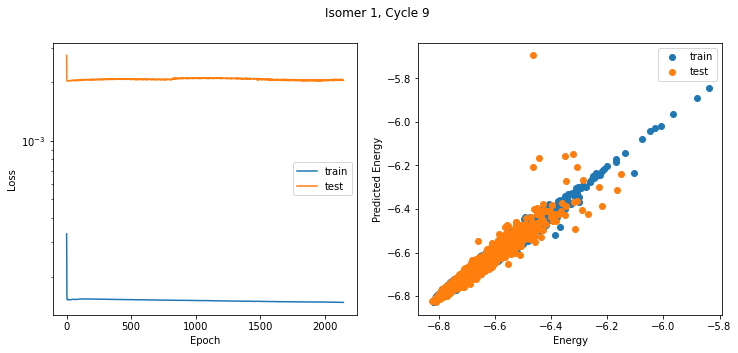

N_samples:  19000
N_samples*0.8:  15200
N_samples*0.2:  3800
N iterations:  30000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  1974
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 3.42e-04 	 2.81e-03 	 3.7e-01
2.0e+02 	 5.00e-05 	 1.54e-04 	 2.04e-03 	 3.7e-01
3.9e+02 	 5.00e-05 	 1.50e-04 	 2.08e-03 	 3.7e-01
5.9e+02 	 5.00e-05 	 1.49e-04 	 2.12e-03 	 3.7e-01
7.9e+02 	 5.00e-05 	 1.48e-04 	 2.12e-03 	 3.7e-01
9.8e+02 	 5.00e-05 	 1.47e-04 	 2.15e-03 	 3.7e-01
1.2e+03 	 5.00e-05 	 1.46e-04 	 2.11e-03 	 3.7e-01
1.4e+03 	 5.00e-05 	 1.45e-04 	 2.11e-03 	 3.7e-01
1.6e+03 	 5.00e-05 	 1.45e-04 	 2.12e-03 	 3.7e-01
1.8e+03 	 5.00e-05 	 1.44e-04 	 2.11e-03 	 3.7e-01
2.0e+03 	 5.00e-05 	 1.44e-04 	 2.13e-03 	 3.7e-01


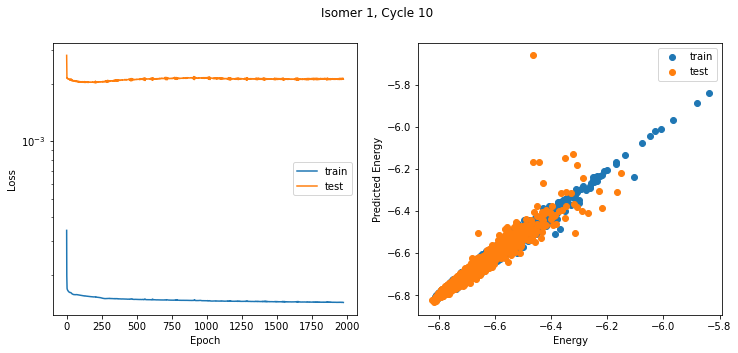

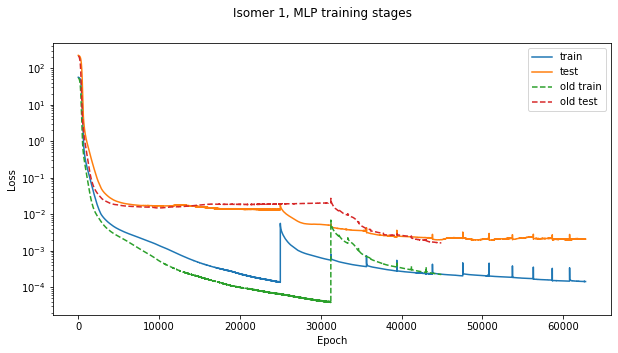

In [44]:
isomer = 1
idx = 32510291#31959913
#hyperparams = {'dim': 12, 
#'n_hidden': 64, 
#'n_layers': 4, 
#'n_iter': 25000, 
#'lr': 5e-5, 
#'bs': 5000, 
#'use_scheduler': False, 
#'step_scheduler': 100, 
#'with_tqdm': False}
#init_n_samples = 1000
#final_n_samples = 16000
#step_n_samples = 300
#skip = 5

models_is1, all_losses = run_training(isomer,
        idx,
        hyperparams,
        init_n_samples,
        final_n_samples,
        step_n_samples,
        skip)

N_samples:  1000
N_samples*0.8:  800
N_samples*0.2:  200
N iterations:  5000
Batch size:  5000
Learning rate:  5e-05
Number of epochs:  5000
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 2.93e+02 	 1.17e+03 	 1.6e+01
5.0e+02 	 5.00e-05 	 5.88e+01 	 2.39e+02 	 4.0e+01
1.0e+03 	 5.00e-05 	 5.52e+00 	 1.68e+01 	 3.8e+00
1.5e+03 	 5.00e-05 	 6.07e-01 	 2.23e+00 	 6.7e-01
2.0e+03 	 5.00e-05 	 2.06e-01 	 1.01e+00 	 1.8e-01
2.5e+03 	 5.00e-05 	 1.14e-01 	 6.31e-01 	 9.6e-02
3.0e+03 	 5.00e-05 	 7.00e-02 	 4.35e-01 	 5.5e-02
3.5e+03 	 5.00e-05 	 4.98e-02 	 3.25e-01 	 3.3e-02
4.0e+03 	 5.00e-05 	 3.89e-02 	 2.55e-01 	 2.1e-02
4.5e+03 	 5.00e-05 	 3.23e-02 	 2.19e-01 	 1.5e-02


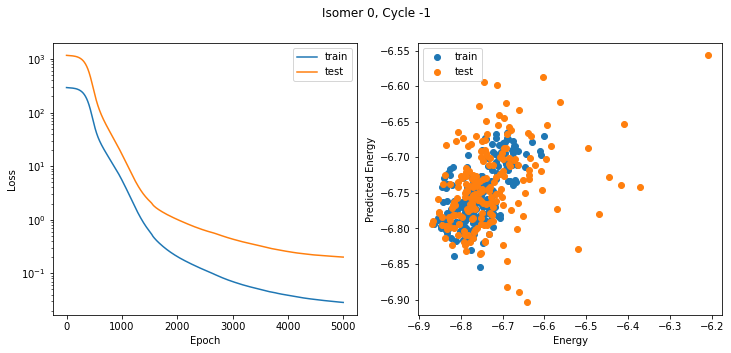

N_samples:  8500
N_samples*0.8:  6800
N_samples*0.2:  1700
N iterations:  30000
Batch size:  5000
Learning rate:  5e-05
Number of epochs:  22059
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 2.66e-02 	 9.41e-02 	 3.0e-01
2.2e+03 	 5.00e-05 	 7.45e-03 	 4.17e-02 	 3.0e-01
4.4e+03 	 5.00e-05 	 3.69e-03 	 2.72e-02 	 3.0e-01
6.6e+03 	 5.00e-05 	 1.91e-03 	 1.77e-02 	 3.0e-01
8.8e+03 	 5.00e-05 	 1.32e-03 	 1.46e-02 	 3.0e-01
1.1e+04 	 5.00e-05 	 1.02e-03 	 1.45e-02 	 3.0e-01
1.3e+04 	 5.00e-05 	 8.38e-04 	 1.43e-02 	 3.0e-01
1.5e+04 	 5.00e-05 	 7.35e-04 	 1.42e-02 	 3.0e-01
1.8e+04 	 5.00e-05 	 6.59e-04 	 1.45e-02 	 3.0e-01
2.0e+04 	 5.00e-05 	 5.99e-04 	 1.45e-02 	 3.0e-01
2.2e+04 	 5.00e-05 	 5.50e-04 	 1.39e-02 	 3.0e-01


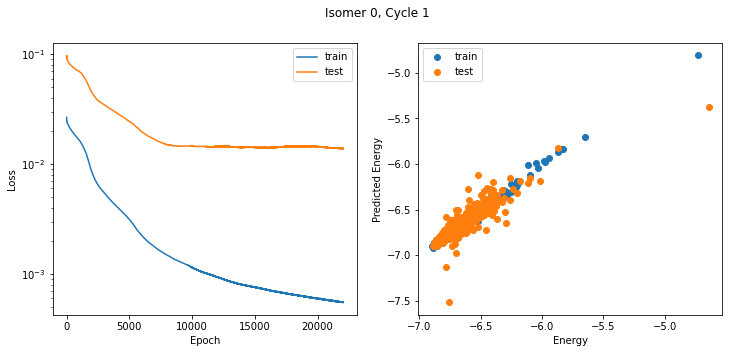

N_samples:  8500
N_samples*0.8:  6800
N_samples*0.2:  1700
N iterations:  30000
Batch size:  5000
Learning rate:  5e-05
Number of epochs:  22059
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 1.71e-03 	 1.79e-02 	 1.4e+00
2.2e+03 	 5.00e-05 	 5.41e-04 	 1.27e-02 	 1.4e+00
4.4e+03 	 5.00e-05 	 4.94e-04 	 1.25e-02 	 1.4e+00
6.6e+03 	 5.00e-05 	 4.63e-04 	 1.25e-02 	 1.4e+00
8.8e+03 	 5.00e-05 	 4.42e-04 	 1.28e-02 	 1.4e+00
1.1e+04 	 5.00e-05 	 4.27e-04 	 1.28e-02 	 1.4e+00
1.3e+04 	 5.00e-05 	 4.15e-04 	 1.27e-02 	 1.4e+00
1.5e+04 	 5.00e-05 	 4.07e-04 	 1.25e-02 	 1.4e+00
1.8e+04 	 5.00e-05 	 3.91e-04 	 1.23e-02 	 1.4e+00
2.0e+04 	 5.00e-05 	 3.81e-04 	 1.23e-02 	 1.4e+00
2.2e+04 	 5.00e-05 	 3.74e-04 	 1.22e-02 	 1.4e+00


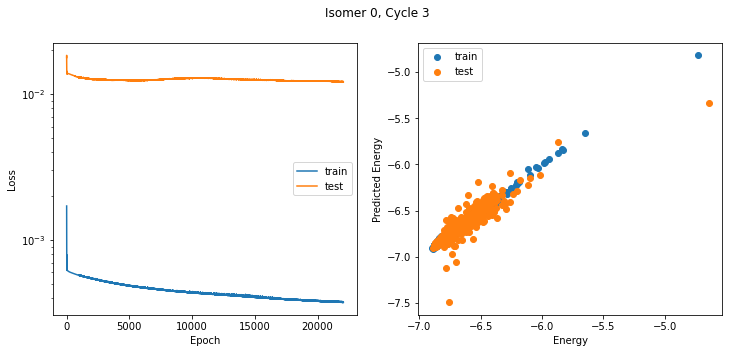

N_samples:  11500
N_samples*0.8:  9200
N_samples*0.2:  2300
N iterations:  30000
Batch size:  5000
Learning rate:  5e-05
Number of epochs:  16304
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 3.94e-03 	 9.79e-03 	 1.2e+00
1.6e+03 	 5.00e-05 	 3.77e-04 	 6.56e-03 	 1.2e+00
3.3e+03 	 5.00e-05 	 3.29e-04 	 6.11e-03 	 1.2e+00
4.9e+03 	 5.00e-05 	 3.03e-04 	 6.04e-03 	 1.2e+00
6.5e+03 	 5.00e-05 	 2.86e-04 	 6.07e-03 	 1.2e+00
8.2e+03 	 5.00e-05 	 2.73e-04 	 6.01e-03 	 1.2e+00
9.8e+03 	 5.00e-05 	 2.65e-04 	 5.90e-03 	 1.2e+00
1.1e+04 	 5.00e-05 	 2.56e-04 	 5.83e-03 	 1.2e+00
1.3e+04 	 5.00e-05 	 2.48e-04 	 5.86e-03 	 1.2e+00
1.5e+04 	 5.00e-05 	 2.44e-04 	 6.01e-03 	 1.2e+00
1.6e+04 	 5.00e-05 	 2.37e-04 	 6.10e-03 	 1.2e+00


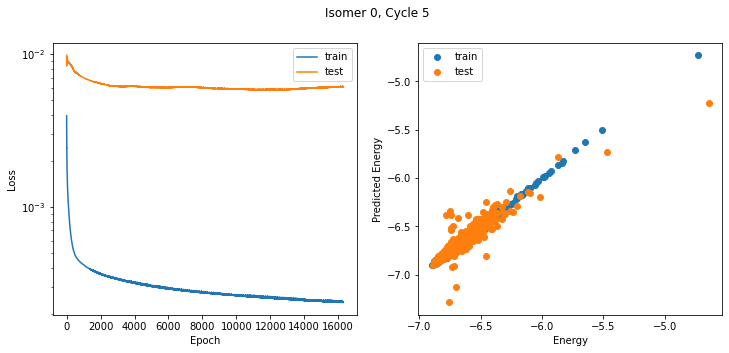

N_samples:  14500
N_samples*0.8:  11600
N_samples*0.2:  2900
N iterations:  30000
Batch size:  5000
Learning rate:  5e-05
Number of epochs:  12931
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 1.11e-03 	 9.57e-03 	 3.4e-01
1.3e+03 	 5.00e-05 	 2.97e-04 	 6.17e-03 	 3.4e-01
2.6e+03 	 5.00e-05 	 2.80e-04 	 6.10e-03 	 3.4e-01
3.9e+03 	 5.00e-05 	 2.75e-04 	 6.23e-03 	 3.4e-01
5.2e+03 	 5.00e-05 	 2.65e-04 	 6.38e-03 	 3.4e-01
6.5e+03 	 5.00e-05 	 2.64e-04 	 6.58e-03 	 3.4e-01
7.8e+03 	 5.00e-05 	 2.53e-04 	 6.72e-03 	 3.4e-01
9.1e+03 	 5.00e-05 	 2.51e-04 	 6.83e-03 	 3.4e-01
1.0e+04 	 5.00e-05 	 2.46e-04 	 6.95e-03 	 3.4e-01
1.2e+04 	 5.00e-05 	 2.42e-04 	 7.04e-03 	 3.4e-01
1.3e+04 	 5.00e-05 	 2.39e-04 	 7.05e-03 	 3.4e-01


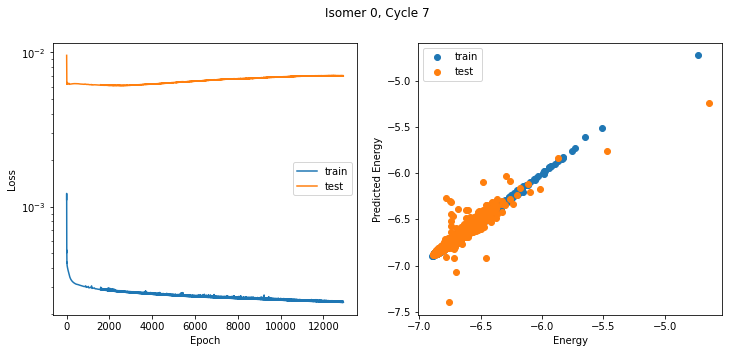

N_samples:  17500
N_samples*0.8:  14000
N_samples*0.2:  3500
N iterations:  30000
Batch size:  5000
Learning rate:  5e-05
Number of epochs:  11628
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 8.77e-04 	 7.95e-03 	 3.8e-01
1.2e+03 	 5.00e-05 	 2.25e-04 	 5.01e-03 	 3.8e-01
2.3e+03 	 5.00e-05 	 2.20e-04 	 4.98e-03 	 3.8e-01
3.5e+03 	 5.00e-05 	 2.16e-04 	 5.03e-03 	 3.8e-01
4.6e+03 	 5.00e-05 	 2.12e-04 	 5.09e-03 	 3.8e-01
5.8e+03 	 5.00e-05 	 2.09e-04 	 5.15e-03 	 3.8e-01
7.0e+03 	 5.00e-05 	 2.07e-04 	 5.20e-03 	 3.8e-01
8.1e+03 	 5.00e-05 	 2.05e-04 	 5.23e-03 	 3.8e-01
9.3e+03 	 5.00e-05 	 2.04e-04 	 5.17e-03 	 3.8e-01
1.0e+04 	 5.00e-05 	 2.02e-04 	 5.18e-03 	 3.8e-01
1.2e+04 	 5.00e-05 	 2.00e-04 	 5.22e-03 	 3.8e-01


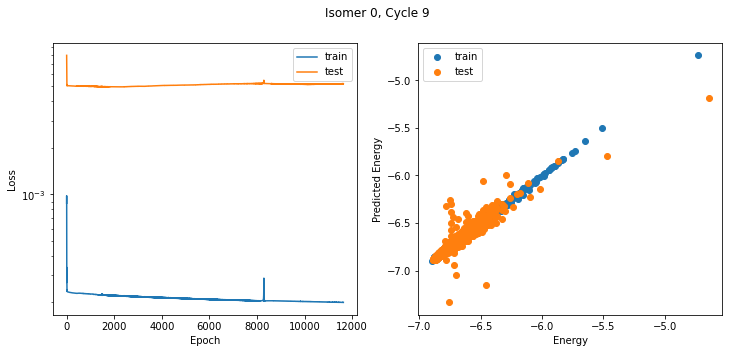

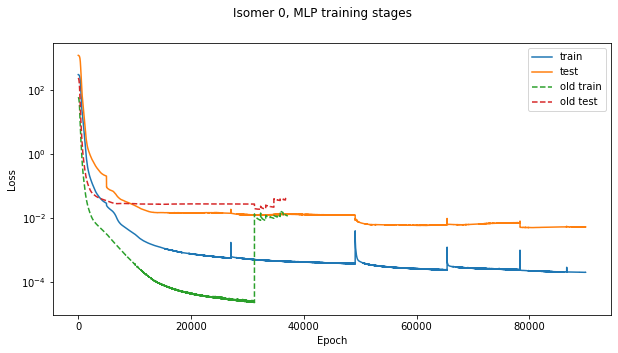

In [45]:
isomer = 0
idx = 31959910
hyperparams = {'dim': 12, 
'n_hidden': 64, 
'n_layers': 4, 
'n_iter': 5000, 
'lr': 5e-5, 
'bs': 5000,
'use_scheduler': False, 
'step_scheduler': 100, 
'with_tqdm': False}
init_n_samples = 1000
final_n_samples = 16000
step_n_samples = 300
skip = 2

models_is0, all_losses_is0 = run_training(isomer,
        idx,
        hyperparams,
        init_n_samples,
        final_n_samples,
        step_n_samples,
        skip)